In [ ]:
# GPU 확인
!nvidia-smi

Mon Apr 13 09:46:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# Ultralytics 설치
!pip install ultralytics==8.3.40 -q

from ultralytics import YOLO
import torch
import os
import yaml
import shutil
from pathlib import Path

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 65.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# # ============================================
# # 방법 1: zip 파일 직접 업로드
# # ============================================
# # Colab 파일 업로드
# from google.colab import files
# uploaded = files.upload()  # zip 파일 선택

# # 업로드된 zip 파일명 자동 감지
# zip_name = list(uploaded.keys())[0]
# print(f"업로드된 파일: {zip_name}")

# # 압축 해제
# !mkdir -p /content/dataset
# !unzip -q -o "{zip_name}" -d /content/dataset

# # 폴더 구조 확인
# !find /content/dataset -type d | head -20
# print("\n--- 파일 수 ---")
# !find /content/dataset -name "*.jpg" -o -name "*.png" | wc -l

Saving Safety Helmet.v5i.yolov8.zip to Safety Helmet.v5i.yolov8.zip
업로드된 파일: Safety Helmet.v5i.yolov8.zip
/content/dataset
/content/dataset/test
/content/dataset/test/labels
/content/dataset/test/images
/content/dataset/valid
/content/dataset/valid/labels
/content/dataset/valid/images
/content/dataset/train
/content/dataset/train/labels
/content/dataset/train/images

--- 파일 수 ---
5000


In [ ]:
# ============================================
# 데이터셋 병합 (기존 + 추가 vest 데이터)
# ============================================
from google.colab import files
import zipfile

# 1) 기존 데이터셋 업로드 + 압축 해제
print("=== 기존 데이터셋 zip 업로드 ===")
uploaded1 = files.upload()
zip1 = list(uploaded1.keys())[0]
!mkdir -p /content/dataset
!unzip -q -o "{zip1}" -d /content/dataset

# 2) 추가 vest 데이터셋 업로드 + 임시 폴더에 해제
print("\n=== 추가 vest 데이터셋 zip 업로드 ===")
uploaded2 = files.upload()
zip2 = list(uploaded2.keys())[0]
!mkdir -p /content/dataset_extra
!unzip -q -o "{zip2}" -d /content/dataset_extra

# 구조 확인
print("\n=== 기존 데이터셋 ===")
!find /content/dataset -type d | head -15
print("\n=== 추가 데이터셋 ===")
!find /content/dataset_extra -type d | head -15

=== 기존 데이터셋 zip 업로드 ===


Saving Safety Helmet.v8-final_260409.yolov8.zip to Safety Helmet.v8-final_260409.yolov8.zip

=== 추가 vest 데이터셋 zip 업로드 ===


Saving PPE Detection-helmet.yolov8.zip to PPE Detection-helmet.yolov8.zip
Saving safety vest.yolov8.zip to safety vest.yolov8.zip

=== 기존 데이터셋 ===
/content/dataset
/content/dataset/train
/content/dataset/train/images
/content/dataset/train/labels
/content/dataset/test
/content/dataset/test/images
/content/dataset/test/labels
/content/dataset/valid
/content/dataset/valid/images
/content/dataset/valid/labels

=== 추가 데이터셋 ===
/content/dataset_extra
/content/dataset_extra/train
/content/dataset_extra/train/images
/content/dataset_extra/train/labels


In [ ]:
# 3) 추가 데이터를 기존 데이터셋에 병합
import shutil
import glob

extra_base = '/content/dataset_extra'
main_base = '/content/dataset'

merged_count = {'images': 0, 'labels': 0}

for split in ['train', 'valid', 'test']:
    for dtype in ['images', 'labels']:
        # 추가 데이터셋에서 해당 폴더 찾기
        # Roboflow 포맷: split/images, split/labels
        extra_dir = os.path.join(extra_base, split, dtype)

        if not os.path.exists(extra_dir):
            # 다른 경로 구조일 수도 있으니 탐색
            alt_paths = glob.glob(f'{extra_base}/**/{split}/{dtype}', recursive=True)
            if alt_paths:
                extra_dir = alt_paths[0]
            else:
                continue

        main_dir = os.path.join(main_base, split, dtype)
        os.makedirs(main_dir, exist_ok=True)

        for f in glob.glob(os.path.join(extra_dir, '*')):
            fname = os.path.basename(f)
            dest = os.path.join(main_dir, fname)

            # 파일명 충돌 시 접두어 추가
            if os.path.exists(dest):
                name, ext = os.path.splitext(fname)
                fname = f"{name}_extra{ext}"
                dest = os.path.join(main_dir, fname)

            shutil.copy2(f, dest)
            merged_count[dtype] += 1

print(f"\n병합 완료: 이미지 {merged_count['images']}장, 라벨 {merged_count['labels']}개 추가")


병합 완료: 이미지 167장, 라벨 167개 추가


In [ ]:
# 4) 병합 후 데이터 검증
from collections import Counter

for split in ['train', 'valid', 'test']:
    img_dir = f'{main_base}/{split}/images'
    lbl_dir = f'{main_base}/{split}/labels'

    if not os.path.exists(img_dir):
        continue

    n_img = len(glob.glob(f'{img_dir}/*'))
    n_lbl = len(glob.glob(f'{lbl_dir}/*.txt'))

    # 클래스 분포
    class_counts = Counter()
    for txt in glob.glob(f'{lbl_dir}/*.txt'):
        with open(txt, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_counts[int(parts[0])] += 1

    print(f"[{split}] 이미지: {n_img} | 라벨: {n_lbl}")
    for cid in sorted(class_counts.keys()):
        print(f"  class {cid}: {class_counts[cid]}개")

    # 이미지-라벨 불일치 체크
    if n_img != n_lbl:
        print(f"  ⚠️ 이미지/라벨 수 불일치!")

print("\n이후 기존 학습 코드(data.yaml 수정, head 제거 등) 그대로 진행하면 됩니다")

[train] 이미지: 3667 | 라벨: 3667
  class 0: 3394개
  class 1: 10736개
  class 2: 11718개
  class 3: 1765개
[valid] 이미지: 1000 | 라벨: 1000
  class 0: 940개
  class 1: 2913개
  class 2: 3259개
  class 3: 505개
[test] 이미지: 500 | 라벨: 500
  class 0: 501개
  class 1: 1416개
  class 2: 1604개
  class 3: 224개

이후 기존 학습 코드(data.yaml 수정, head 제거 등) 그대로 진행하면 됩니다


In [ ]:
# 기존 data.yaml 확인
yaml_path = "/content/dataset/data.yaml"
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("=== 원본 data.yaml ===")
print(yaml.dump(data_config, default_flow_style=False))

# head 클래스의 인덱스 찾기
original_names = data_config['names']
if isinstance(original_names, dict):
    head_idx = [k for k, v in original_names.items() if v == 'head']
    keep_classes = {k: v for k, v in original_names.items() if v != 'head'}
else:
    head_idx = [i for i, name in enumerate(original_names) if name == 'head']
    keep_classes = [name for name in original_names if name != 'head']

print(f"\nhead 클래스 인덱스: {head_idx}")
print(f"사용할 클래스: {keep_classes}")

=== 원본 data.yaml ===
names:
- head
- helmet
- person
- vest
nc: 4
roboflow:
  license: CC BY 4.0
  project: safety-helmet-4mhdt-m4od4
  url: https://universe.roboflow.com/s-workspace-31kqe/safety-helmet-4mhdt-m4od4/dataset/8
  version: 8
  workspace: s-workspace-31kqe
test: ../test/images
train: ../train/images
val: ../valid/images


head 클래스 인덱스: [0]
사용할 클래스: ['helmet', 'person', 'vest']


In [ ]:
# head 어노테이션 제거 + 클래스 인덱스 재매핑
import glob

# 원본 클래스 목록에서 매핑 테이블 생성
if isinstance(original_names, dict):
    old_names = original_names
else:
    old_names = {i: name for i, name in enumerate(original_names)}

# head가 아닌 클래스만 새 인덱스로 매핑
new_idx = 0
remap = {}  # old_idx -> new_idx
new_names = {}
for old_i in sorted(old_names.keys()):
    if old_names[old_i] != 'head':
        remap[old_i] = new_idx
        new_names[new_idx] = old_names[old_i]
        new_idx += 1

print(f"인덱스 매핑: {remap}")
print(f"새 클래스: {new_names}")

# 모든 라벨 파일 수정
label_dirs = glob.glob("/content/dataset/**/labels", recursive=True)
total_removed = 0
total_remapped = 0

for label_dir in label_dirs:
    for txt_file in glob.glob(os.path.join(label_dir, "*.txt")):
        with open(txt_file, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            old_class = int(parts[0])
            if old_class in remap:
                parts[0] = str(remap[old_class])
                new_lines.append(' '.join(parts) + '\n')
                total_remapped += 1
            else:
                total_removed += 1

        with open(txt_file, 'w') as f:
            f.writelines(new_lines)

print(f"\n제거된 head 어노테이션: {total_removed}개")
print(f"유지된 어노테이션: {total_remapped}개")

인덱스 매핑: {1: 0, 2: 1, 3: 2}
새 클래스: {0: 'helmet', 1: 'person', 2: 'vest'}

제거된 head 어노테이션: 4835개
유지된 어노테이션: 34140개


In [ ]:
# 수정된 data.yaml 저장
data_config['names'] = new_names
data_config['nc'] = len(new_names)

# 경로를 절대경로로 수정
data_config['path'] = '/content/dataset'
# train/val/test 경로가 상대경로인지 확인
for key in ['train', 'val', 'test']:
    if key in data_config:
        p = data_config[key]
        if not os.path.isabs(p):
            # 상대경로 유지 (path 기준)
            pass

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("=== 수정된 data.yaml ===")
with open(yaml_path, 'r') as f:
    print(f.read())

=== 수정된 data.yaml ===
names:
  0: helmet
  1: person
  2: vest
nc: 3
path: /content/dataset
roboflow:
  license: CC BY 4.0
  project: safety-helmet-4mhdt-m4od4
  url: https://universe.roboflow.com/s-workspace-31kqe/safety-helmet-4mhdt-m4od4/dataset/8
  version: 8
  workspace: s-workspace-31kqe
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
# 클래스별 어노테이션 분포 확인
from collections import Counter

for split in ['train', 'valid', 'test']:
    label_path = f"/content/dataset/{split}/labels"
    if not os.path.exists(label_path):
        # Roboflow 포맷에 따라 경로가 다를 수 있음
        label_path = f"/content/dataset/{split}/labels"

    if not os.path.exists(label_path):
        print(f"{split}: 폴더 없음")
        continue

    class_counts = Counter()
    n_images = len(glob.glob(os.path.join(label_path, "*.txt")))

    for txt_file in glob.glob(os.path.join(label_path, "*.txt")):
        with open(txt_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_counts[int(parts[0])] += 1

    print(f"\n[{split}] 이미지: {n_images}장")
    for cls_id in sorted(class_counts.keys()):
        cls_name = new_names.get(cls_id, f"unknown_{cls_id}")
        print(f"  {cls_name}: {class_counts[cls_id]}개")


[train] 이미지: 3667장
  helmet: 10736개
  person: 11718개
  vest: 1765개

[valid] 이미지: 1000장
  helmet: 2913개
  person: 3259개
  vest: 505개

[test] 이미지: 500장
  helmet: 1416개
  person: 1604개
  vest: 224개


In [ ]:
# YOLOv8n 모델 로드 (pretrained COCO weights)
model = YOLO('yolov8n.pt')

# =============================================
# 학습 파라미터 (T4 GPU + 소규모 데이터셋 최적화)
# =============================================
results = model.train(
    data=yaml_path,

    # --- 기본 설정 ---
    epochs=150,              # 데이터 적으니 충분히 돌림
    imgsz=640,               # 표준 입력 크기
    batch=16,                # T4 16GB 기준 안정적

    # --- Optimizer ---
    optimizer='AdamW',       # 소규모 데이터에서 SGD보다 안정적
    lr0=0.001,               # AdamW 초기 학습률
    lrf=0.01,                # 최종 학습률 비율 (lr0 * lrf)
    weight_decay=0.0005,     # 과적합 방지
    warmup_epochs=5,         # 초반 안정화
    warmup_momentum=0.8,

    # --- Augmentation (소규모 데이터 → 강하게) ---
    hsv_h=0.015,             # 색조 변환
    hsv_s=0.7,               # 채도 변환
    hsv_v=0.4,               # 명도 변환
    degrees=10.0,            # 회전 (건설현장: 카메라 약간 틀어질 수 있음)
    translate=0.2,           # 이동
    scale=0.5,               # 스케일 변환 (다양한 거리)
    shear=2.0,               # 전단
    flipud=0.1,              # 상하 반전 (약하게)
    fliplr=0.5,              # 좌우 반전
    mosaic=1.0,              # 모자이크 (소규모 데이터에 효과적)
    mixup=0.15,              # MixUp (과적합 억제)
    copy_paste=0.1,          # Copy-Paste augmentation
    erasing=0.3,             # Random Erasing (가림 상황 대응)

    # --- 학습 안정화 ---
    cos_lr=True,             # Cosine LR scheduler
    close_mosaic=15,         # 마지막 15 epoch: mosaic 끄고 fine-tune
    patience=30,             # Early stopping patience

    # --- Loss weights ---
    box=7.5,                 # Box loss 가중치
    cls=0.5,                 # Classification loss
    dfl=1.5,                 # Distribution focal loss

    # --- 기타 ---
    workers=2,               # Colab 환경 안정성
    project='/content/runs',
    name='ppe_yolov8n',
    exist_ok=True,
    pretrained=True,         # COCO pretrained (전이학습)
    verbose=True,
    seed=42,
)

100%|██████████| 6.25M/6.25M [00:00<00:00, 483MB/s]

New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)


engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/dataset/data.yaml, epochs=150, time=None, patience=30, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=2, project=/content/runs, name=ppe_yolov8n, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=15, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=False, optimize=F

100%|██████████| 755k/755k [00:00<00:00, 185MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

                   all       1000       6677      0.815      0.769      0.816      0.399

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


    129/150       2.4G      1.484     0.9452      1.404         12        640: 100%|██████████| 230/230 [00:30<00:00,  7.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:04<00:00,  7.29it/s]


                   all       1000       6677      0.812      0.771      0.815      0.397
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 99, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

129 epochs completed in 1.288 hours.
Optimizer stripped from /content/runs/ppe_yolov8n/weights/last.pt, 6.3MB
Optimizer stripped from /content/runs/ppe_yolov8n/weights/best.pt, 6.3MB

Validating /content/runs/ppe_yolov8n/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 168 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:06<00:00,  4.85it/s]


                   all       1000       6677      0.796      0.769      0.815      0.402
                helmet        919       2913      0.885      0.818      0.889      0.441
                person        959       3259      0.841      0.829      0.863      0.443
                  vest        252        505      0.662      0.659      0.692      0.321
Speed: 0.2ms preprocess, 0.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/ppe_yolov8n


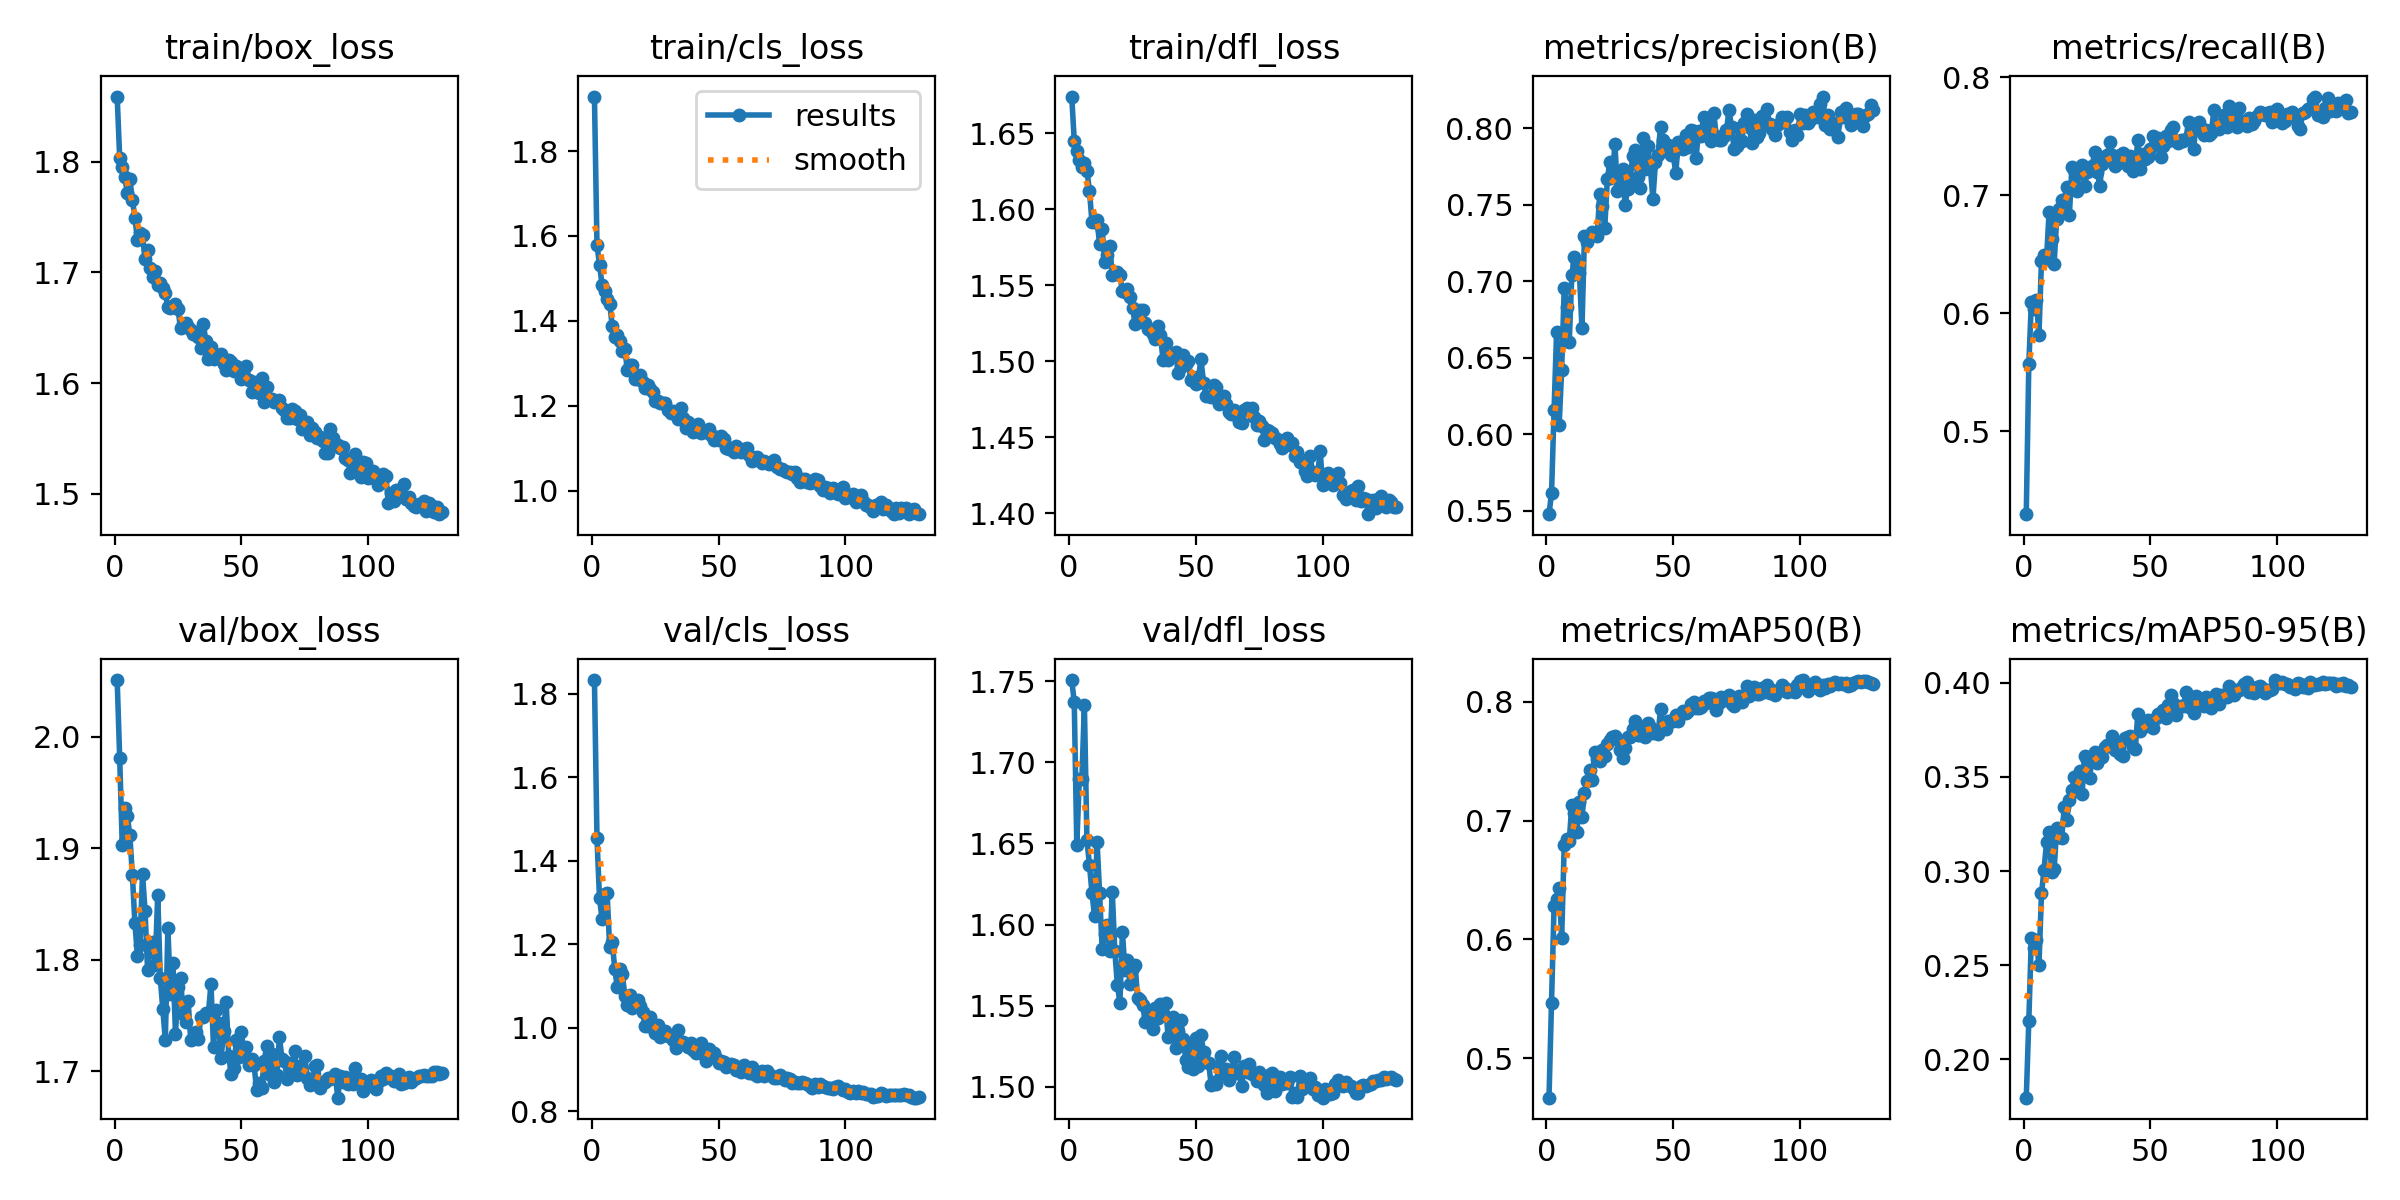


=== Confusion Matrix (Normalized) ===


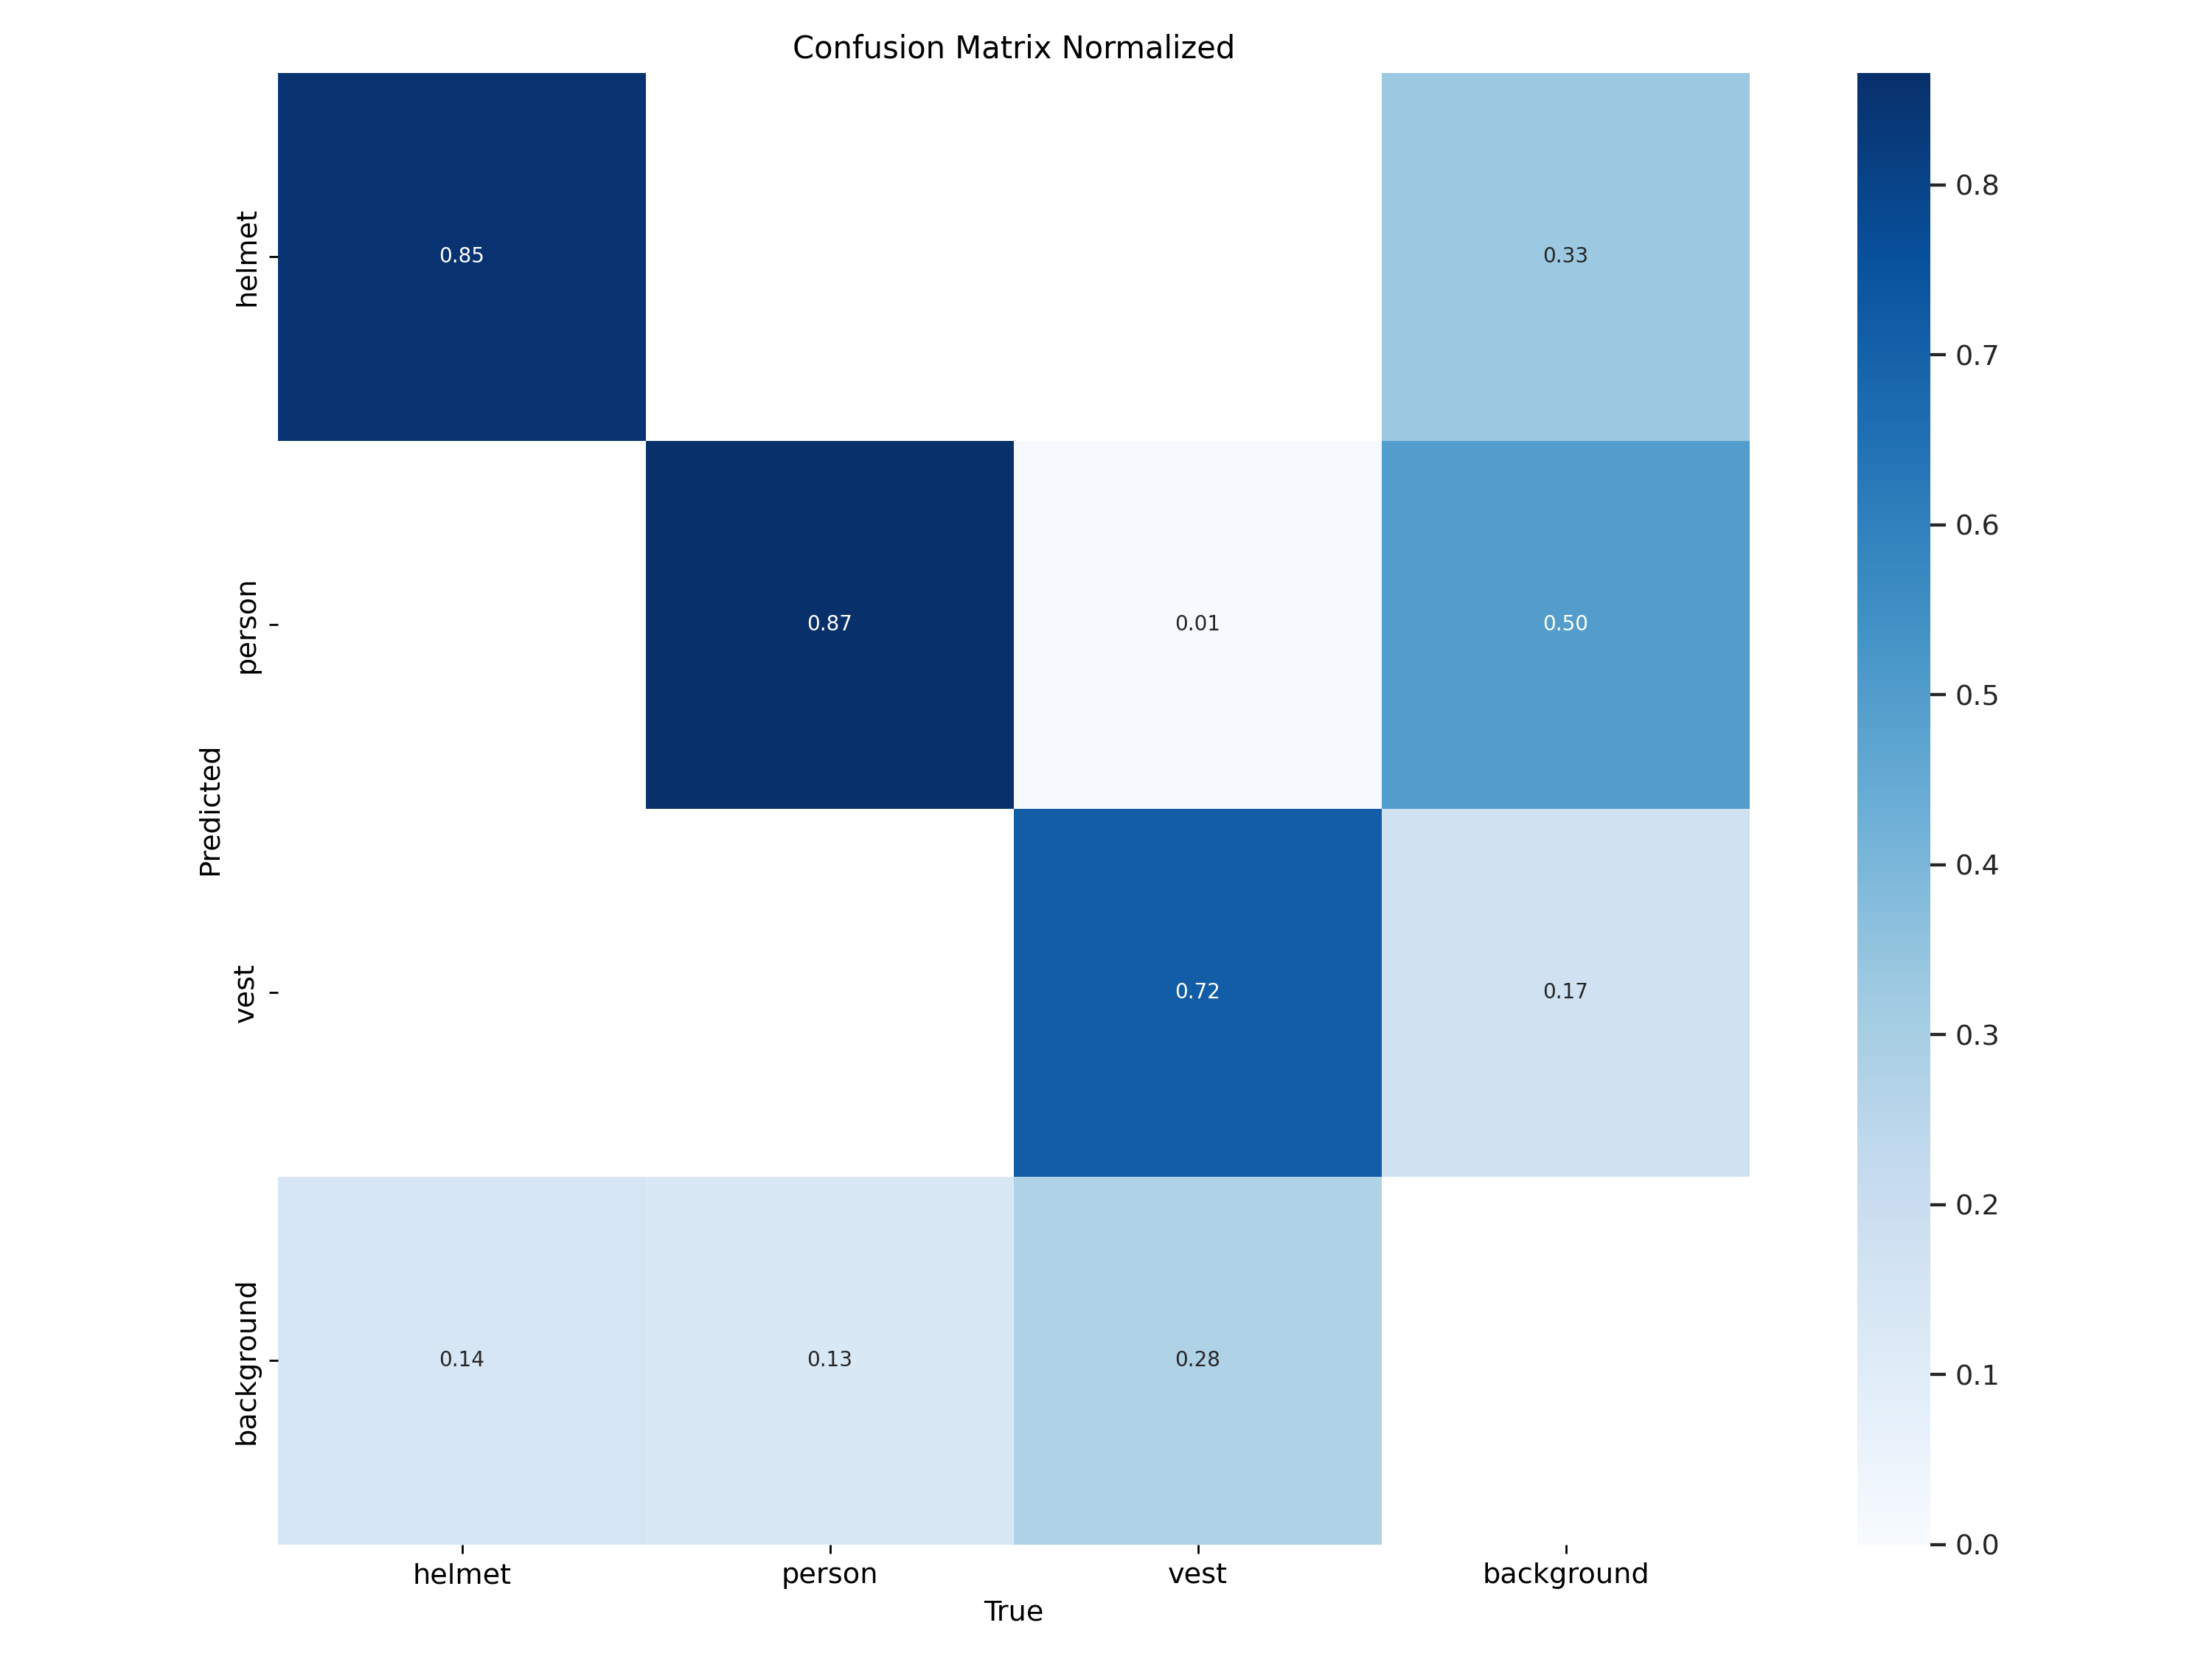


=== PR Curve ===


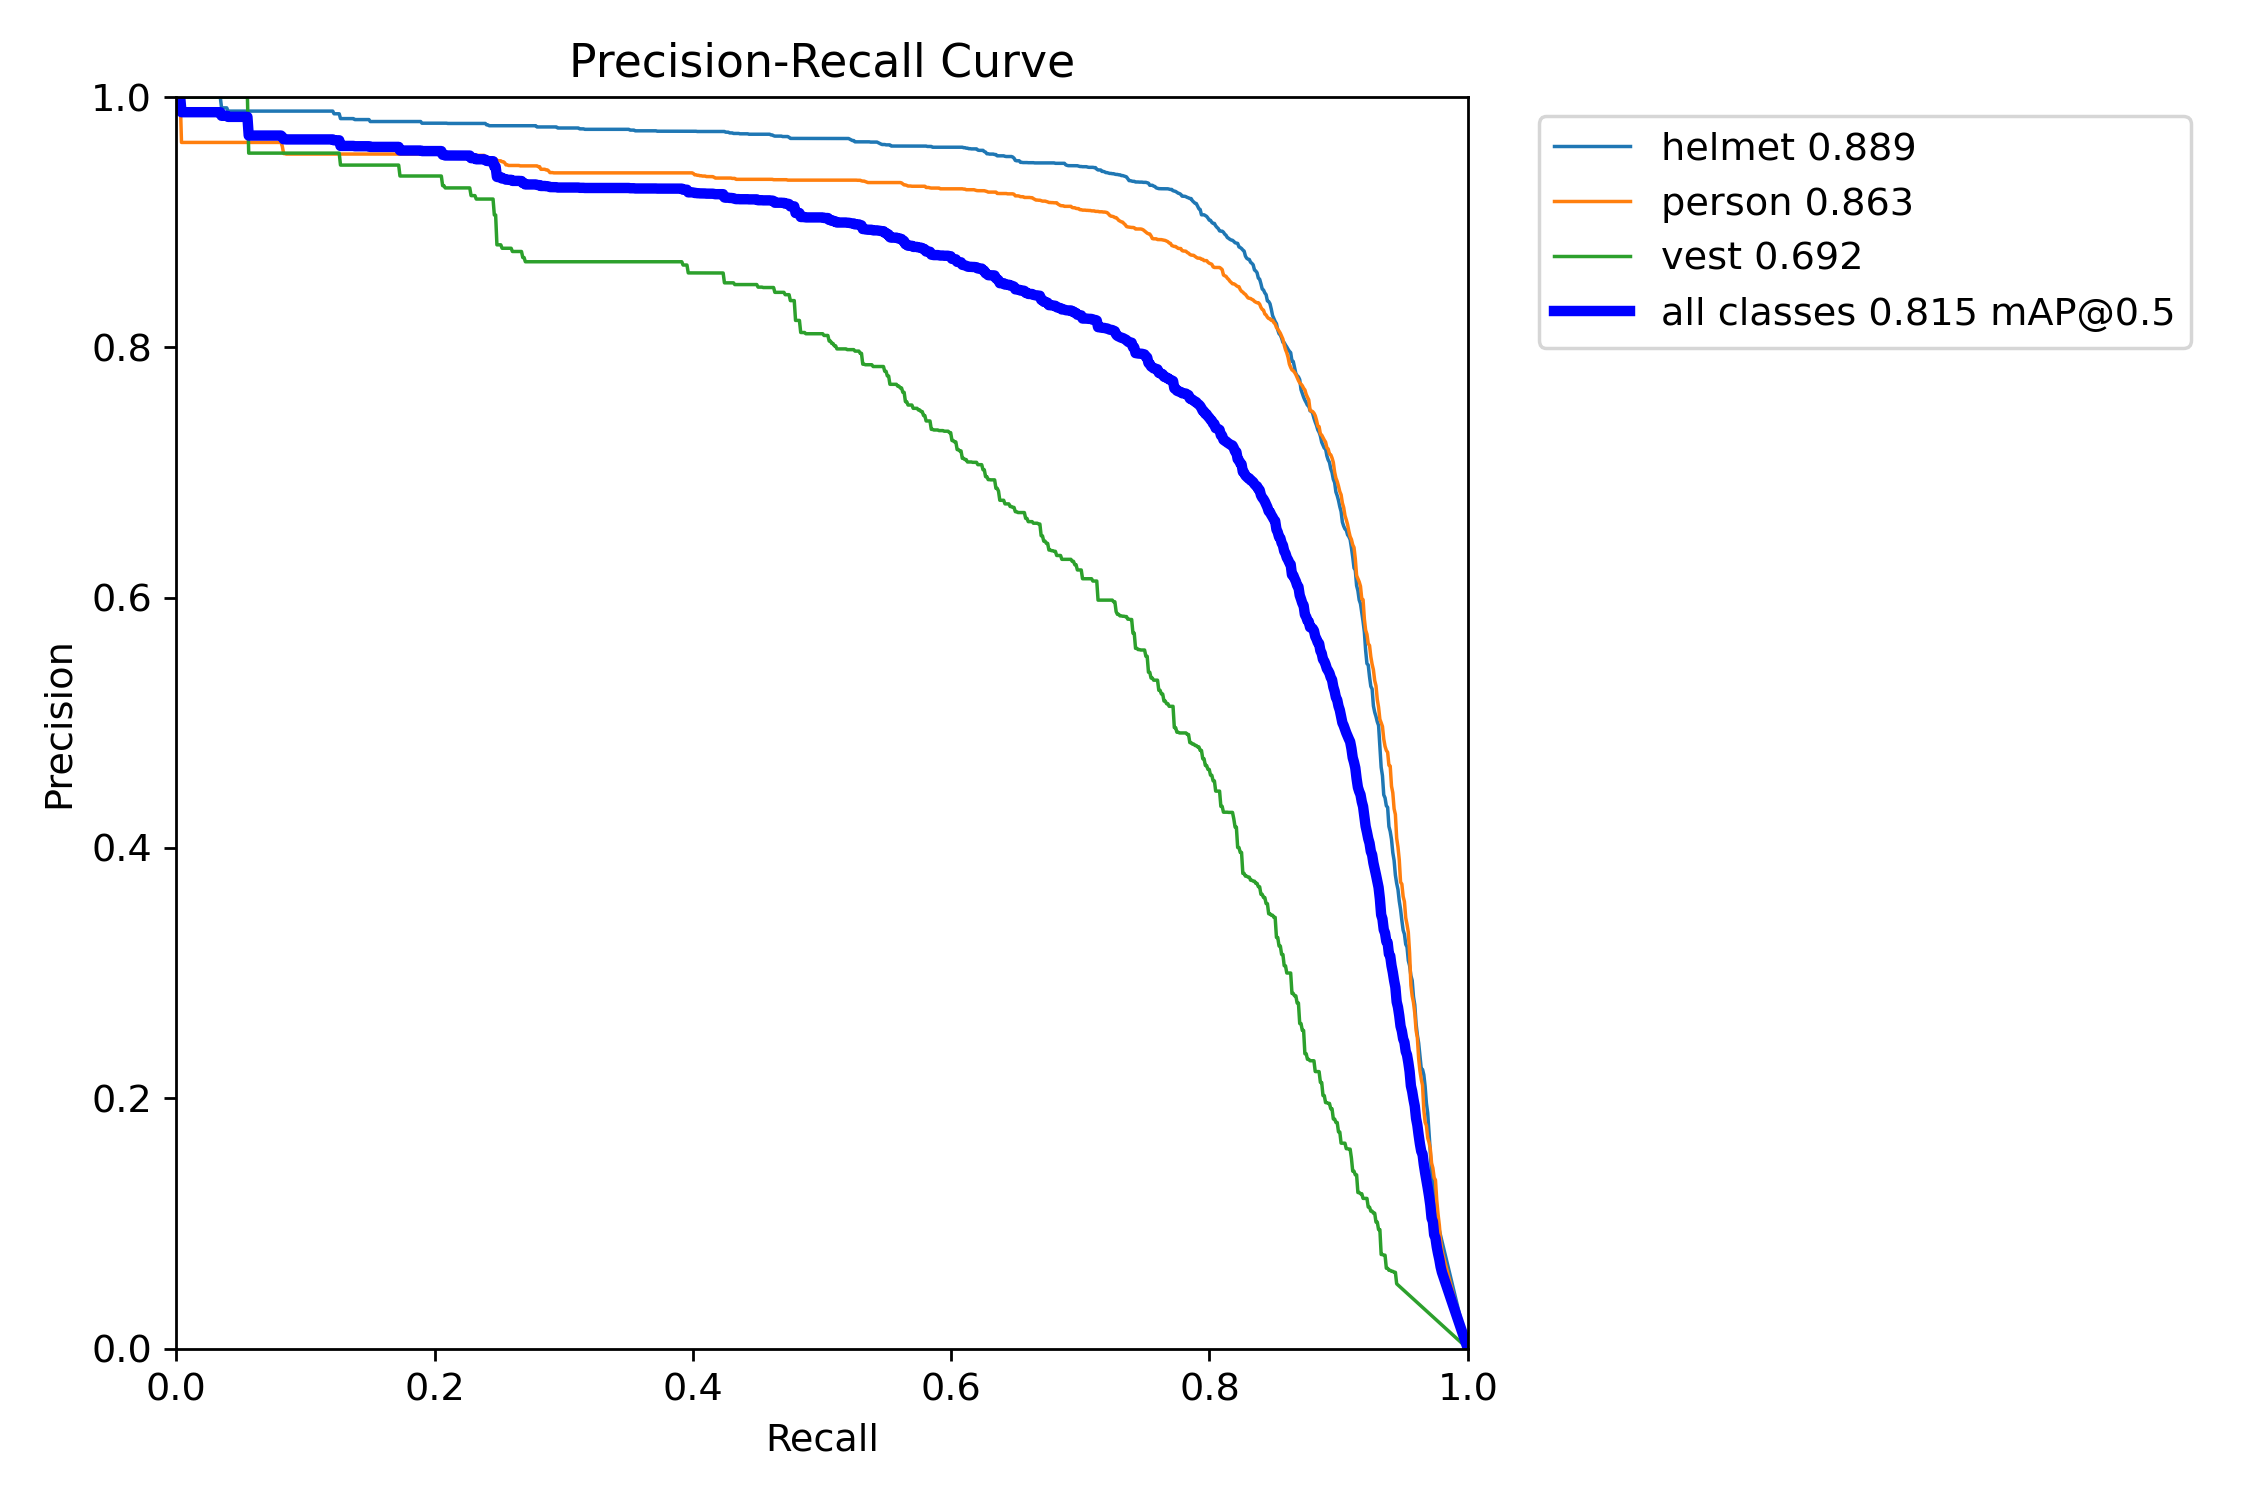

In [ ]:
# 학습 결과 시각화
from IPython.display import Image, display

result_dir = '/content/runs/ppe_yolov8n'

# 학습 곡선
if os.path.exists(f'{result_dir}/results.png'):
    display(Image(filename=f'{result_dir}/results.png', width=900))

# Confusion Matrix
if os.path.exists(f'{result_dir}/confusion_matrix_normalized.png'):
    print("\n=== Confusion Matrix (Normalized) ===")
    display(Image(filename=f'{result_dir}/confusion_matrix_normalized.png', width=600))

# PR Curve
if os.path.exists(f'{result_dir}/PR_curve.png'):
    print("\n=== PR Curve ===")
    display(Image(filename=f'{result_dir}/PR_curve.png', width=600))

In [ ]:
# 검증 이미지 확인
if os.path.exists(f'{result_dir}/val_batch0_pred.png'):
    print("=== Validation Predictions ===")
    display(Image(filename=f'{result_dir}/val_batch0_pred.png', width=800))

In [ ]:
# best 모델로 validation
best_model = YOLO(f'{result_dir}/weights/best.pt')
metrics = best_model.val(data=yaml_path, imgsz=640, batch=16)

print("\n" + "="*50)
print("최종 성능 요약")
print("="*50)
print(f"mAP@50     : {metrics.box.map50:.4f}")
print(f"mAP@50-95  : {metrics.box.map:.4f}")
print(f"Precision  : {metrics.box.mp:.4f}")
print(f"Recall     : {metrics.box.mr:.4f}")

print("\n--- 클래스별 AP@50 ---")
for i, ap in enumerate(metrics.box.ap50):
    print(f"  {new_names[i]:10s}: {ap:.4f}")

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 168 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/dataset/valid/labels.cache... 1000 images, 8 backgrounds, 0 corrupt: 100%|██████████| 1000/1000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 63/63 [00:07<00:00,  8.26it/s]


                   all       1000       6677      0.796      0.768      0.814      0.401
                helmet        919       2913      0.885      0.818      0.889      0.441
                person        959       3259      0.841      0.829      0.864      0.443
                  vest        252        505      0.661      0.657       0.69       0.32
Speed: 0.1ms preprocess, 1.3ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/val

최종 성능 요약
mAP@50     : 0.8143
mAP@50-95  : 0.4014
Precision  : 0.7958
Recall     : 0.7681

--- 클래스별 AP@50 ---
  helmet    : 0.8891
  person    : 0.8639
  vest      : 0.6899


-------------------

In [ ]:
# Colab에서 웹캠 캡처 → 추론 → 결과 표시
# (Colab은 직접 cv2.VideoCapture가 안 되므로 JS로 캡처)

from IPython.display import display, Javascript, HTML, Image as IPImage
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import numpy as np
import cv2
import time

# 웹캠 캡처 JS 함수
def init_webcam():
    js = Javascript('''
        // Define functions on window object to ensure global scope
        window.initCamera = async function() {
            const div = document.createElement('div');
            const video = document.createElement('video');
            video.style.display = 'block';
            video.width = 640;
            video.height = 480;
            div.appendChild(video);

            const stream = await navigator.mediaDevices.getUserMedia(
                {video: {width: 640, height: 480}}
            );
            video.srcObject = stream;
            await video.play();

            // 캔버스로 프레임 캡처
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;

            // 글로벌에 저장
            window._video = video;
            window._canvas = canvas;

            return [video.videoWidth, video.videoHeight];
        };

        window.captureFrame = async function() {
            const canvas = window._canvas;
            const video = window._video;
            canvas.getContext('2d').drawImage(video, 0, 0);
            return canvas.toDataURL('image/jpeg', 0.8);
        };

        window.stopCamera = async function() {
            if (window._video && window._video.srcObject) {
                window._video.srcObject.getTracks().forEach(t => t.stop());
            }
        };
    ''')
    display(js)

init_webcam()
print("웹캠 JS 함수 로드 완료")

<IPython.core.display.Javascript object>

웹캠 JS 함수 로드 완료


In [ ]:
init_webcam() # 재실행하여 JS 함수를 다시 로드
dims = eval_js('initCamera()')
print(f"카메라 해상도: {dims}")

<IPython.core.display.Javascript object>

카메라 해상도: [640, 480]


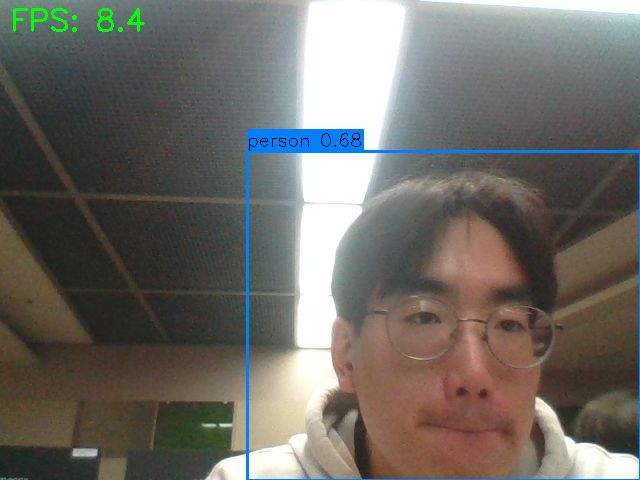

FPS: 8.4 | Detections: 1


MessageError: ReferenceError: stopCamera is not defined

In [ ]:
# 실시간 추론 루프
# 중지하려면 런타임 > 실행 중단 (Ctrl+M+I)

from IPython.display import display, Javascript, HTML, Image as IPImage, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import time
from ultralytics import YOLO # Assuming YOLO is already imported
import os
import io

# =============================================
# 웹캠 캡처 JS 함수 (이 셀 내에서 직접 정의)
# =============================================
js_code = """
    // Define functions on window object to ensure global scope
    window.initCamera = async function() {
        const div = document.createElement('div');
        const video = document.createElement('video');
        video.style.display = 'block';
        video.width = 640;
        video.height = 480;
        div.appendChild(video);

        const stream = await navigator.mediaDevices.getUserMedia(
            {video: {width: 640, height: 480}}
        );
        video.srcObject = stream;
        await video.play();

        // 캔버스로 프레임 캡처
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        // 글로벌에 저장
        window._video = video;
        window._canvas = canvas;

        return [video.videoWidth, video.videoHeight];
    };

    window.captureFrame = async function() {
        const canvas = window._canvas;
        const video = window._video;
        canvas.getContext('2d').drawImage(video, 0, 0);
        return canvas.toDataURL('image/jpeg', 0.8);
    };

    window.stopCamera = async function() {
        if (window._video && window._video.srcObject) {
            window._video.srcObject.getTracks().forEach(t => t.stop());
        }
    };
"""
display(Javascript(js_code))
print("웹캠 JS 함수 로드 완료")

# 클래스별 색상 (BGR)
CLASS_COLORS = {
    'person': (255, 128, 0),    # 주황
    'helmet': (0, 255, 0),      # 초록
    'vest':   (0, 200, 255),    # 노랑
}

best_model = YOLO(f'{result_dir}/weights/best.pt')

# 카메라 초기화는 루프 시작 전 한번만 수행
dims = eval_js('initCamera()')
print(f"카메라 해상도: {dims}")

try:
    # 무한 루프로 변경하여 계속 실행되도록 합니다.
    while True:
        # JS에서 프레임 캡처
        data_url = eval_js('captureFrame()')

        # base64 → numpy array
        binary = b64decode(data_url.split(',')[1])
        img_array = np.frombuffer(binary, dtype=np.uint8)
        frame = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

        if frame is None:
            continue

        # 추론
        t0 = time.time()
        results = best_model.predict(
            frame,
            imgsz=640,
            conf=0.4,
            iou=0.5,
            verbose=False
        )
        dt = time.time() - t0
        fps = 1.0 / dt if dt > 0 else 0

        # 결과 그리기
        annotated = frame.copy()

        if len(results) > 0 and results[0].boxes is not None:
            boxes = results[0].boxes
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                conf = float(box.conf[0])
                cls_id = int(box.cls[0])
                # new_names 변수는 이전 셀에서 정의되었으므로 사용 가능합니다.
                cls_name = new_names.get(cls_id, f'cls_{cls_id}')
                color = CLASS_COLORS.get(cls_name, (255, 255, 255))

                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                label = f'{cls_name} {conf:.2f}'
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
                cv2.rectangle(annotated, (x1, y1-th-8), (x1+tw, y1), color, -1)
                cv2.putText(annotated, label, (x1, y1-5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1)

        # FPS 표시
        cv2.putText(annotated, f'FPS: {fps:.1f}', (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # Colab에 표시 (BGR → RGB)
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        pil_img = PIL.Image.fromarray(annotated_rgb)

        # JPEG로 변환해서 표시
        buf = io.BytesIO()
        pil_img.save(buf, format='JPEG', quality=80)

        clear_output(wait=True)
        display(IPImage(data=buf.getvalue(), width=640))
        print(f'FPS: {fps:.1f} | '
              f'Detections: {len(results[0].boxes) if results[0].boxes is not None else 0}')

except KeyboardInterrupt:
    print("\n중단됨")

finally:
    # 카메라 정리
    eval_js('stopCamera()')
    print("카메라 종료")

In [ ]:
# (선택) 단일 프레임 캡처 후 추론 결과 확인
# 실시간이 아니라 한 장만 찍어서 자세히 보고 싶을 때

data_url = eval_js('captureFrame()')
binary = b64decode(data_url.split(',')[1])
img_array = np.frombuffer(binary, dtype=np.uint8)
frame = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

results = best_model.predict(frame, imgsz=640, conf=0.3, verbose=False)

# Ultralytics 내장 시각화
annotated = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
display(PIL.Image.fromarray(annotated_rgb))

# 탐지 결과 상세
if results[0].boxes is not None:
    print(f"\n탐지된 객체: {len(results[0].boxes)}개")
    for box in results[0].boxes:
        cls_name = new_names.get(int(box.cls[0]), 'unknown')
        conf = float(box.conf[0])
        print(f"  {cls_name}: {conf:.3f}")

In [ ]:
# 카메라 종료
eval_js('stopCamera()')
print("카메라 종료 완료")

-----------------------------

In [ ]:
# ONNX export (Hailo DFC 변환을 위해)
best_model.export(
    format='onnx',
    imgsz=640,
    opset=13,           # Hailo 호환 opset
    simplify=True,      # ONNX simplifier 적용
    dynamic=False,      # 고정 입력 크기 (Edge 배포용)
)

print(f"\nONNX 파일: {result_dir}/weights/best.onnx")
onnx_size = os.path.getsize(f'{result_dir}/weights/best.onnx') / (1024*1024)
print(f"파일 크기: {onnx_size:.1f} MB")

In [ ]:
# Google Drive에 저장
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/PPE_Model'
os.makedirs(save_dir, exist_ok=True)

# best.pt, best.onnx, 학습 결과 복사
shutil.copy(f'{result_dir}/weights/best.pt', save_dir)
shutil.copy(f'{result_dir}/weights/best.onnx', save_dir)
shutil.copy(f'{result_dir}/results.csv', save_dir)
if os.path.exists(f'{result_dir}/results.png'):
    shutil.copy(f'{result_dir}/results.png', save_dir)

print(f"저장 완료: {save_dir}")
!ls -lh {save_dir}

In [ ]:
# 또는 직접 다운로드
# files.download(f'{result_dir}/weights/best.pt')
# files.download(f'{result_dir}/weights/best.onnx')